Menghubungkan Ke GDrive

In [2]:
from google.colab import drive
drive.mount('/content/drive')
#import

Mounted at /content/drive


Import Library dan Proses Membaca Dataset

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

df_cancer = pd.read_csv('/content/drive/MyDrive/PRAKTIKUM ML/Praktikum08/Data/data.csv')
df_cancer.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


Pra-pemrosesan Data

In [17]:
df_cancer = df_cancer.drop(columns=['id', df_cancer.columns[-1]])
print(df_cancer.shape)

(569, 31)


Pengecekan Missing Values

In [18]:
print("Missing values per column:")
print(df_cancer.isnull().sum())

Missing values per column:
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


Encoding Kategorikal

In [19]:
df_cancer['diagnosis'].replace({'M': 1, 'B': 0}, inplace=True)
print("\nValue Counts for Diagnosis (Encoded):")
print(df_cancer['diagnosis'].value_counts())


Value Counts for Diagnosis (Encoded):
diagnosis
0    357
1    212
Name: count, dtype: int64


/tmp/ipython-input-2924780779.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_cancer['diagnosis'].replace({'M': 1, 'B': 0}, inplace=True)
/tmp/ipython-input-2924780779.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_cancer['diagnosis'].replace({'M': 1, 'B': 0}, inplace=True)


Memisahkan Fitur (X) dan Target (Y)

In [20]:
X = df_cancer.drop(columns=['diagnosis'])
Y = df_cancer['diagnosis']
print(X.shape, Y.shape)

(569, 30) (569,)


Pembagian Data (Train-Test Split)

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, stratify=Y, random_state=42
)
print(X_train.shape, X_test.shape)

(455, 30) (114, 30)


Scaling

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# Melatih scaler pada data training dan menerapkannya
X_train_scaled = scaler.fit_transform(X_train)
# Menerapkan scaler pada data testing
X_test_scaled = scaler.transform(X_test)

Pemodelan Gaussian Naive Bayes

In [25]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# Membuat dan melatih model Naive Bayes
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, Y_train)

GaussianNB()

Accuracy Score

In [26]:
print("Training Accuracy (NB):", accuracy_score(Y_train, train_pred_nb))
print("Testing Accuracy (NB):", accuracy_score(Y_test, test_pred_nb))

Training Accuracy (NB): 0.945054945054945
Testing Accuracy (NB): 0.9210526315789473


Classification Report

In [27]:
from sklearn.metrics import classification_report

print("\nClassification Report (NB) on Test Data:")
print(classification_report(Y_test, test_pred_nb, target_names=['Benign (0)', 'Malignant (1)']))


Classification Report (NB) on Test Data:
               precision    recall  f1-score   support

   Benign (0)       0.92      0.96      0.94        72
Malignant (1)       0.92      0.86      0.89        42

     accuracy                           0.92       114
    macro avg       0.92      0.91      0.91       114
 weighted avg       0.92      0.92      0.92       114



Cross-Validation

In [28]:
from sklearn.model_selection import cross_val_score
import numpy as np

cv_nb = cross_val_score(nb_model, X, Y, cv=5, scoring='accuracy')

print("\nNaive Bayes Cross Validation Accuracy (5-Fold):")
print("Scores:", cv_nb)
print("Mean Accuracy:", cv_nb.mean())
print("Std Deviation:", cv_nb.std())


Naive Bayes Cross Validation Accuracy (5-Fold):
Scores: [0.92105263 0.92105263 0.94736842 0.94736842 0.95575221]
Mean Accuracy: 0.9385188635305075
Std Deviation: 0.014585994424363306


Countplot

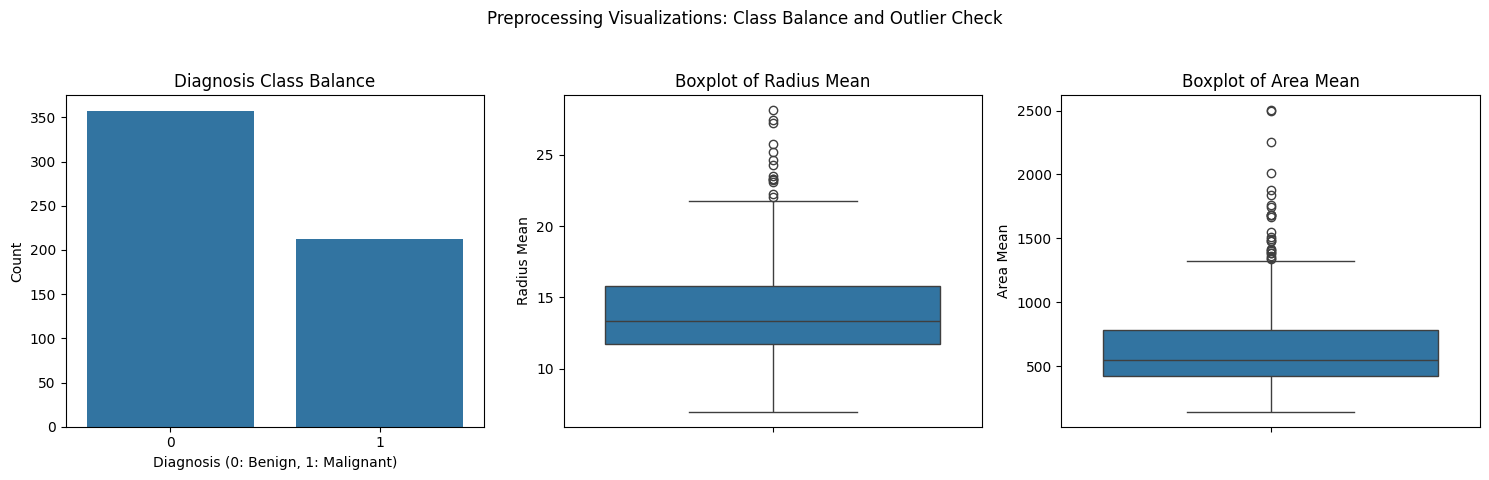

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
# Diasumsikan df_cancer sudah dimuat, dihapus kolom yang tidak relevan, dan 'diagnosis' sudah di-encode

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))
plt.suptitle('Preprocessing Visualizations: Class Balance and Outlier Check')

# Countplot untuk Target (Diagnosis)
sns.countplot(x='diagnosis', data=df_cancer, ax=axes[0])
axes[0].set_title('Diagnosis Class Balance')
axes[0].set_xlabel('Diagnosis (0: Benign, 1: Malignant)')
axes[0].set_ylabel('Count')

# Boxplot untuk radius_mean (Pengecekan Outlier)
sns.boxplot(y='radius_mean', data=df_cancer, ax=axes[1])
axes[1].set_title('Boxplot of Radius Mean')
axes[1].set_ylabel('Radius Mean')

# Boxplot untuk area_mean (Pengecekan Outlier)
sns.boxplot(y='area_mean', data=df_cancer, ax=axes[2])
axes[2].set_title('Boxplot of Area Mean')
axes[2].set_ylabel('Area Mean')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Confusion Matrix

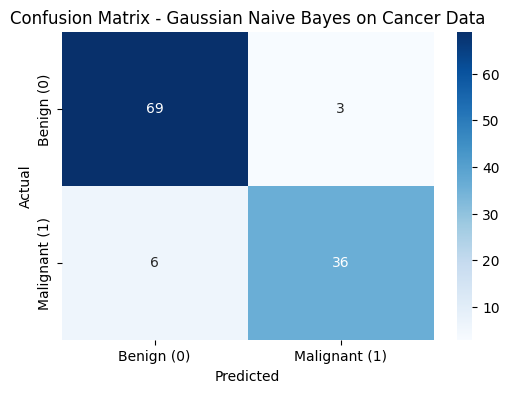

In [29]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm_nb = confusion_matrix(Y_test, test_pred_nb)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_nb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=['Benign (0)', 'Malignant (1)'],
    yticklabels=['Benign (0)', 'Malignant (1)']
)
plt.title("Confusion Matrix - Gaussian Naive Bayes on Cancer Data")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()